# NASA Battery Data Visualization by Entity

This notebook creates visualizations for NASA battery dataset, showing feature trends for each battery entity separately. It loads preprocessed data from the unified folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import glob
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def load_nasa_processed_data():
    """
    Load preprocessed NASA battery data from unified folder
    """
    base_folder = "datasets/NASA/processed"
    
    # Get all battery train files
    train_files = glob.glob(os.path.join(base_folder, "B*_train.pkl"))
    
    battery_data = {}
    
    for train_file in train_files:
        # Extract battery ID from filename
        battery_id = os.path.basename(train_file).replace('_train.pkl', '')
        test_file = os.path.join(base_folder, f"{battery_id}_test.pkl")
        
        print(f"Loading data for battery {battery_id}...")
        
        # Load train data
        if os.path.exists(train_file) and os.path.exists(test_file):
            with open(train_file, 'rb') as f:
                train_data = pickle.load(f)
                
            with open(test_file, 'rb') as f:
                test_data = pickle.load(f)
                
            # Combine train and test data for visualization
            combined_data = np.concatenate([train_data, test_data], axis=0)
            
            # Create DataFrame with feature names
            feature_names = ['capacity', 'voltage_measured', 'current_measured', 
                           'temperature_measured', 'current_charge', 'voltage_charge']
            df = pd.DataFrame(data=combined_data, columns=feature_names)
            
            battery_data[battery_id] = df
            
            print(f"Loaded {battery_id} data with shape: {combined_data.shape}")
        else:
            print(f"Missing data files for battery {battery_id}")
    
    return battery_data

In [3]:
def visualize_battery_features_combined(battery_data):
    """
    Create combined feature trend visualization for all battery entities
    """
    # Define features to visualize
    features = ['capacity', 'voltage_measured', 'current_measured', 
                'temperature_measured', 'current_charge', 'voltage_charge']
    
    # Create separate plots for each battery
    for battery_id, df in battery_data.items():
        # Create a single plot with all features for this battery
        fig, ax = plt.subplots(1, 1, figsize=(15, 8))

        fig.suptitle(f'Battery {battery_id} Feature Trends', fontsize=16)

        # Generate a color map for different features
        colors = plt.cm.get_cmap('tab10', len(features))

        # Plot each feature for this battery
        for idx, feature in enumerate(features):
            ax.plot(df.index, df[feature], linewidth=1, label=feature, color=colors(idx))

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()


In [4]:
def visualize_battery_features_separate(battery_data):
    """
    Create feature trend visualization for each battery entity separately
    """
    # Define features to visualize
    features = ['capacity', 'voltage_measured', 'current_measured', 
                'temperature_measured', 'current_charge', 'voltage_charge']
    
    # Create separate plots for each battery
    for battery_id, df in battery_data.items():
        fig, axes = plt.subplots(len(features), 1, figsize=(15, 3*len(features)))
        if len(features) == 1:
            axes = [axes]
            
        fig.suptitle(f'Battery {battery_id} Feature Trends', fontsize=16)
        
        # Plot each feature
        for idx, feature in enumerate(features):
            axes[idx].plot(df.index, df[feature], linewidth=1)
            axes[idx].set_title(f'{feature}')
            axes[idx].set_xlabel('Time')
            axes[idx].set_ylabel(feature)
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [ ]:
# Load NASA battery data
battery_data = load_nasa_processed_data()

C:\Users\chenmj\AppData\Local\Temp\ipykernel_14892\2440189263.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(features))


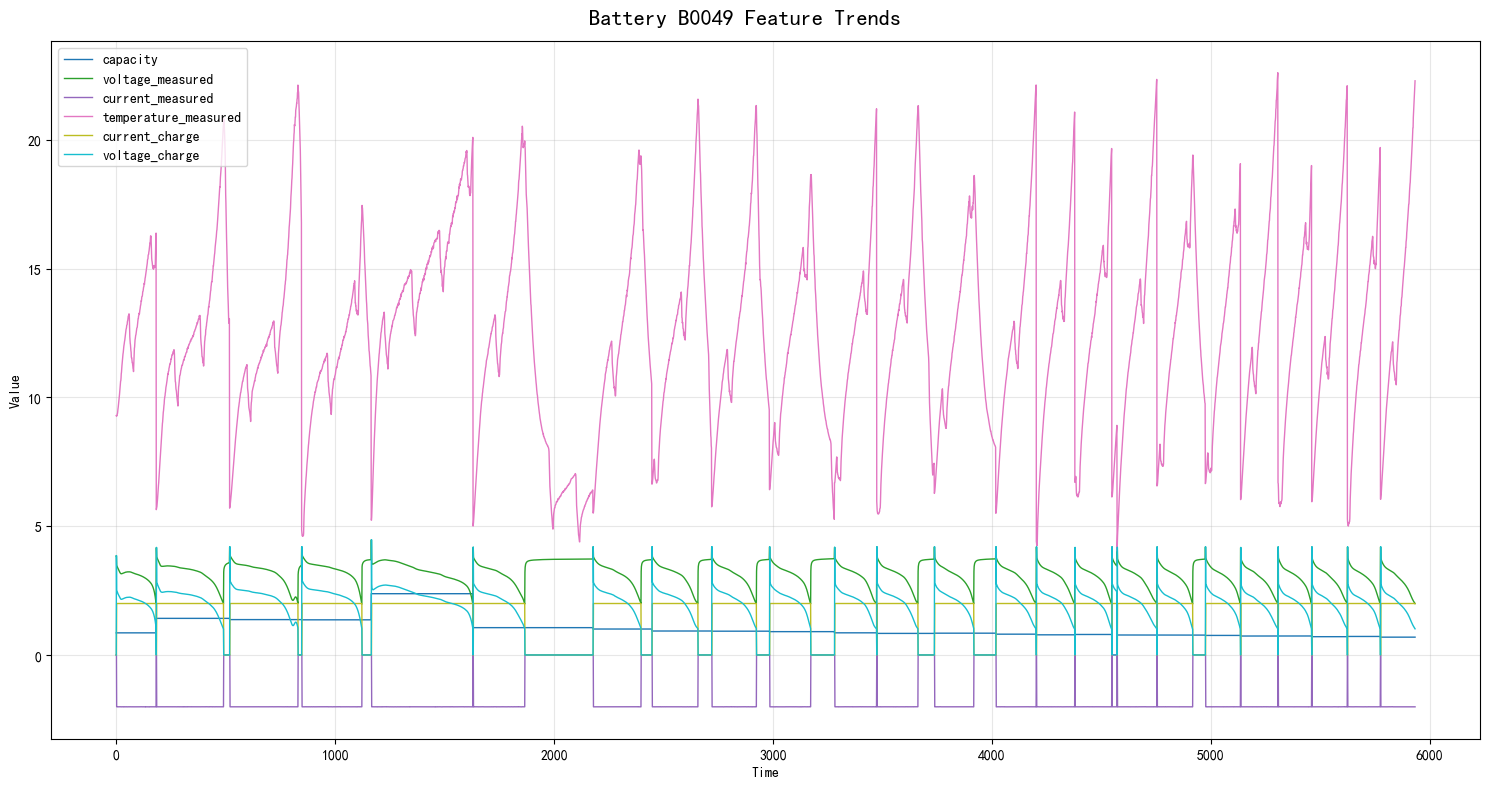

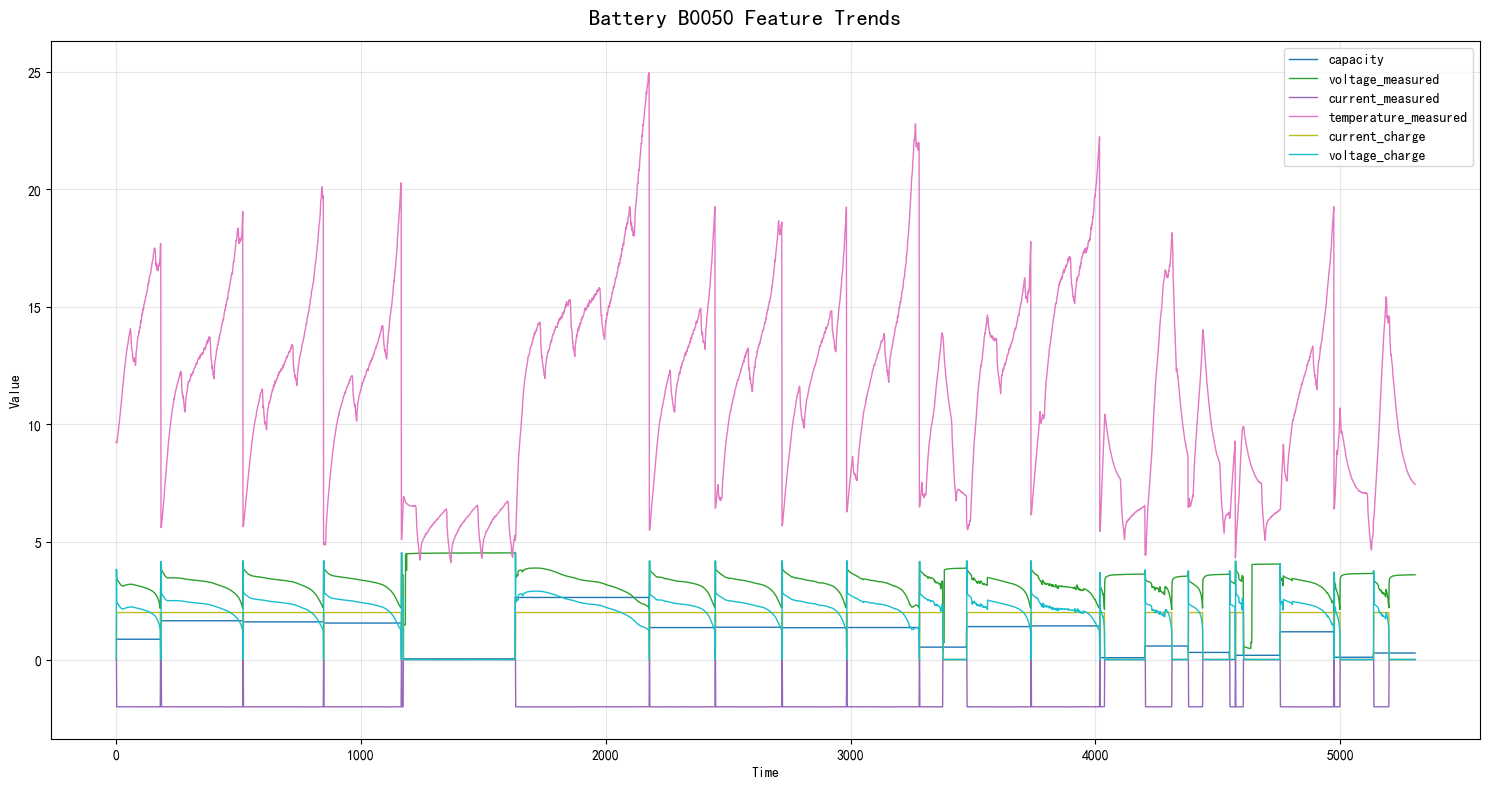

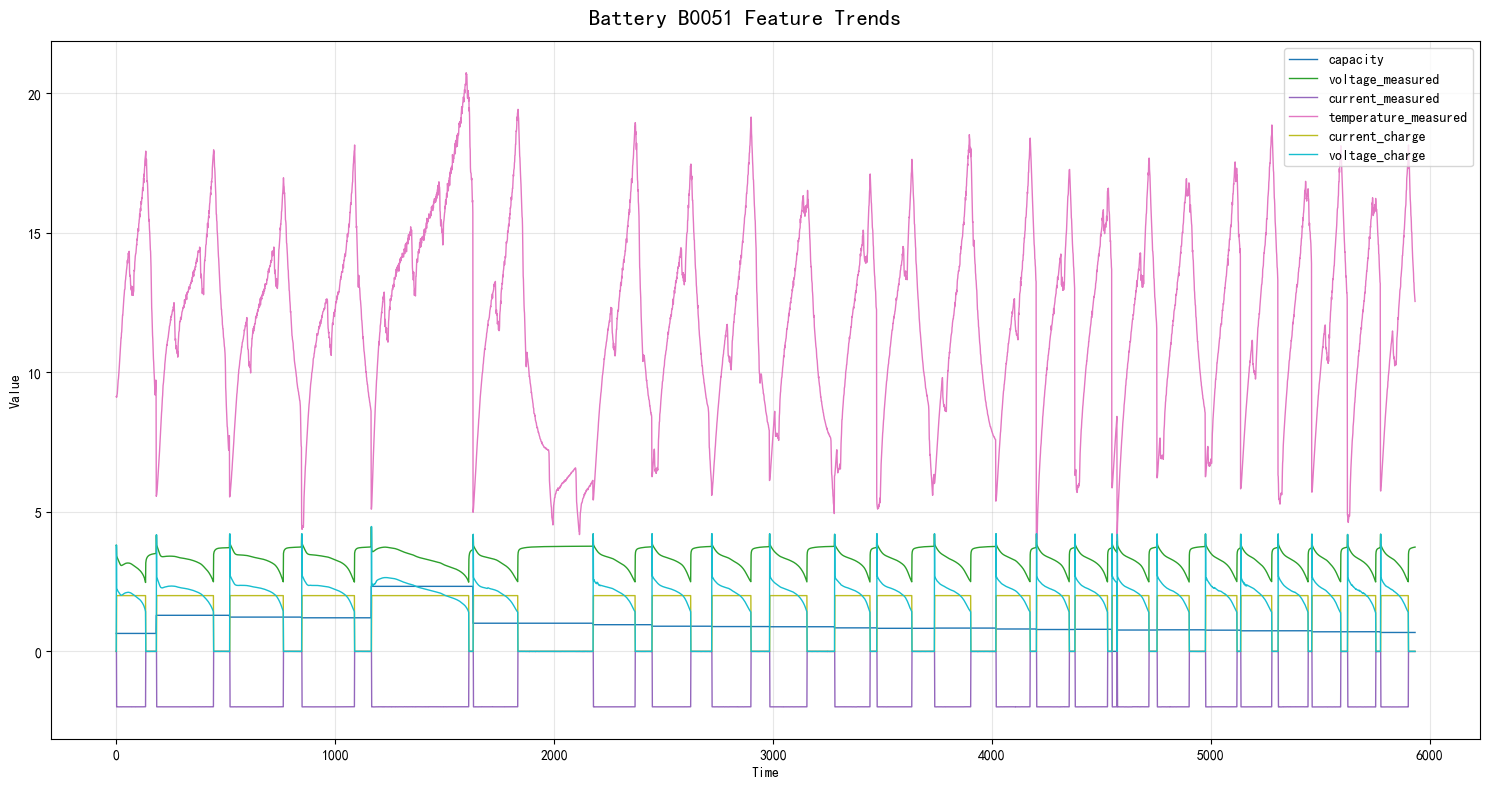

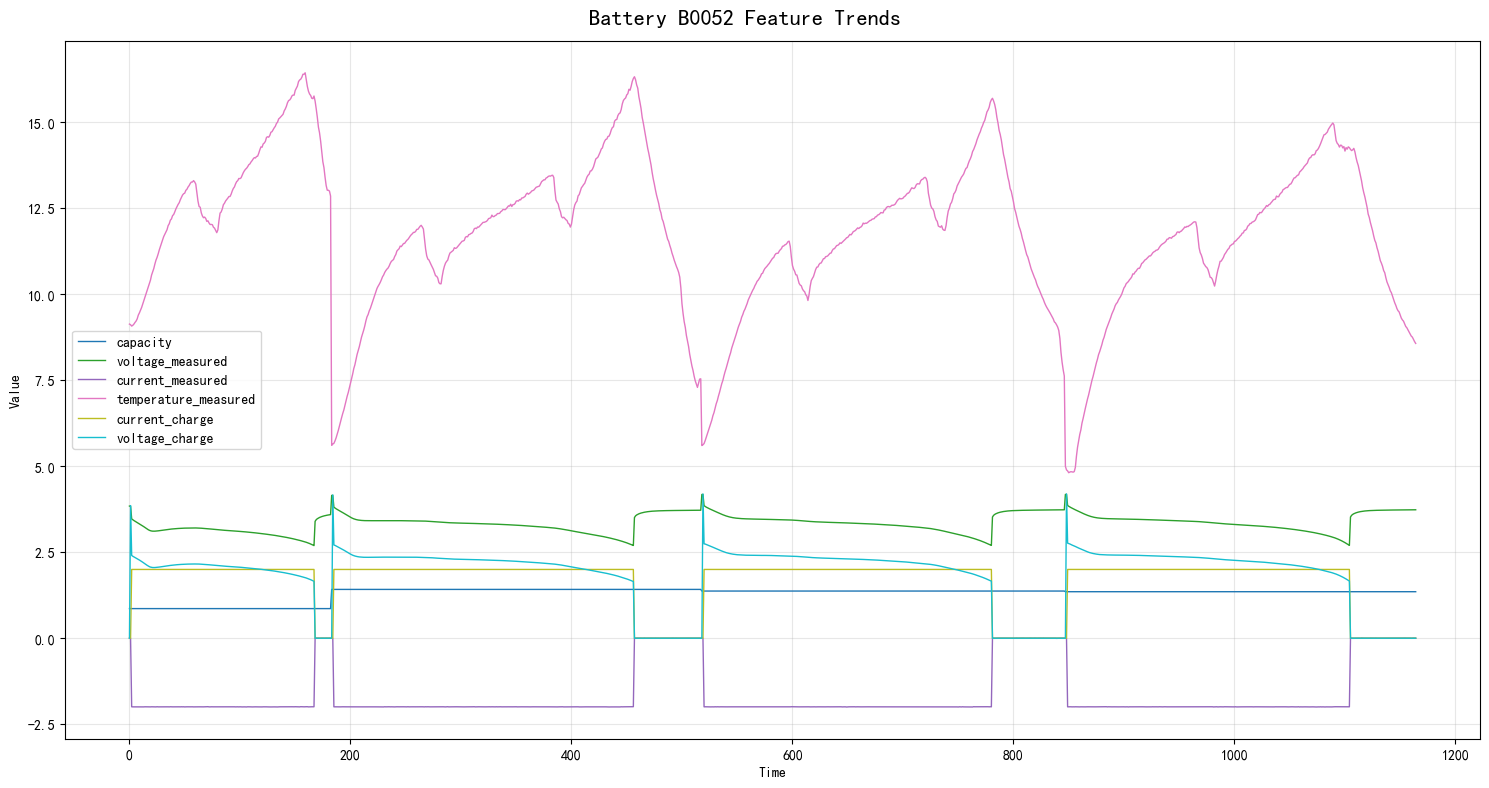

In [30]:
# Visualize feature trends for all batteries in a single chart
visualize_battery_features_combined(battery_data)

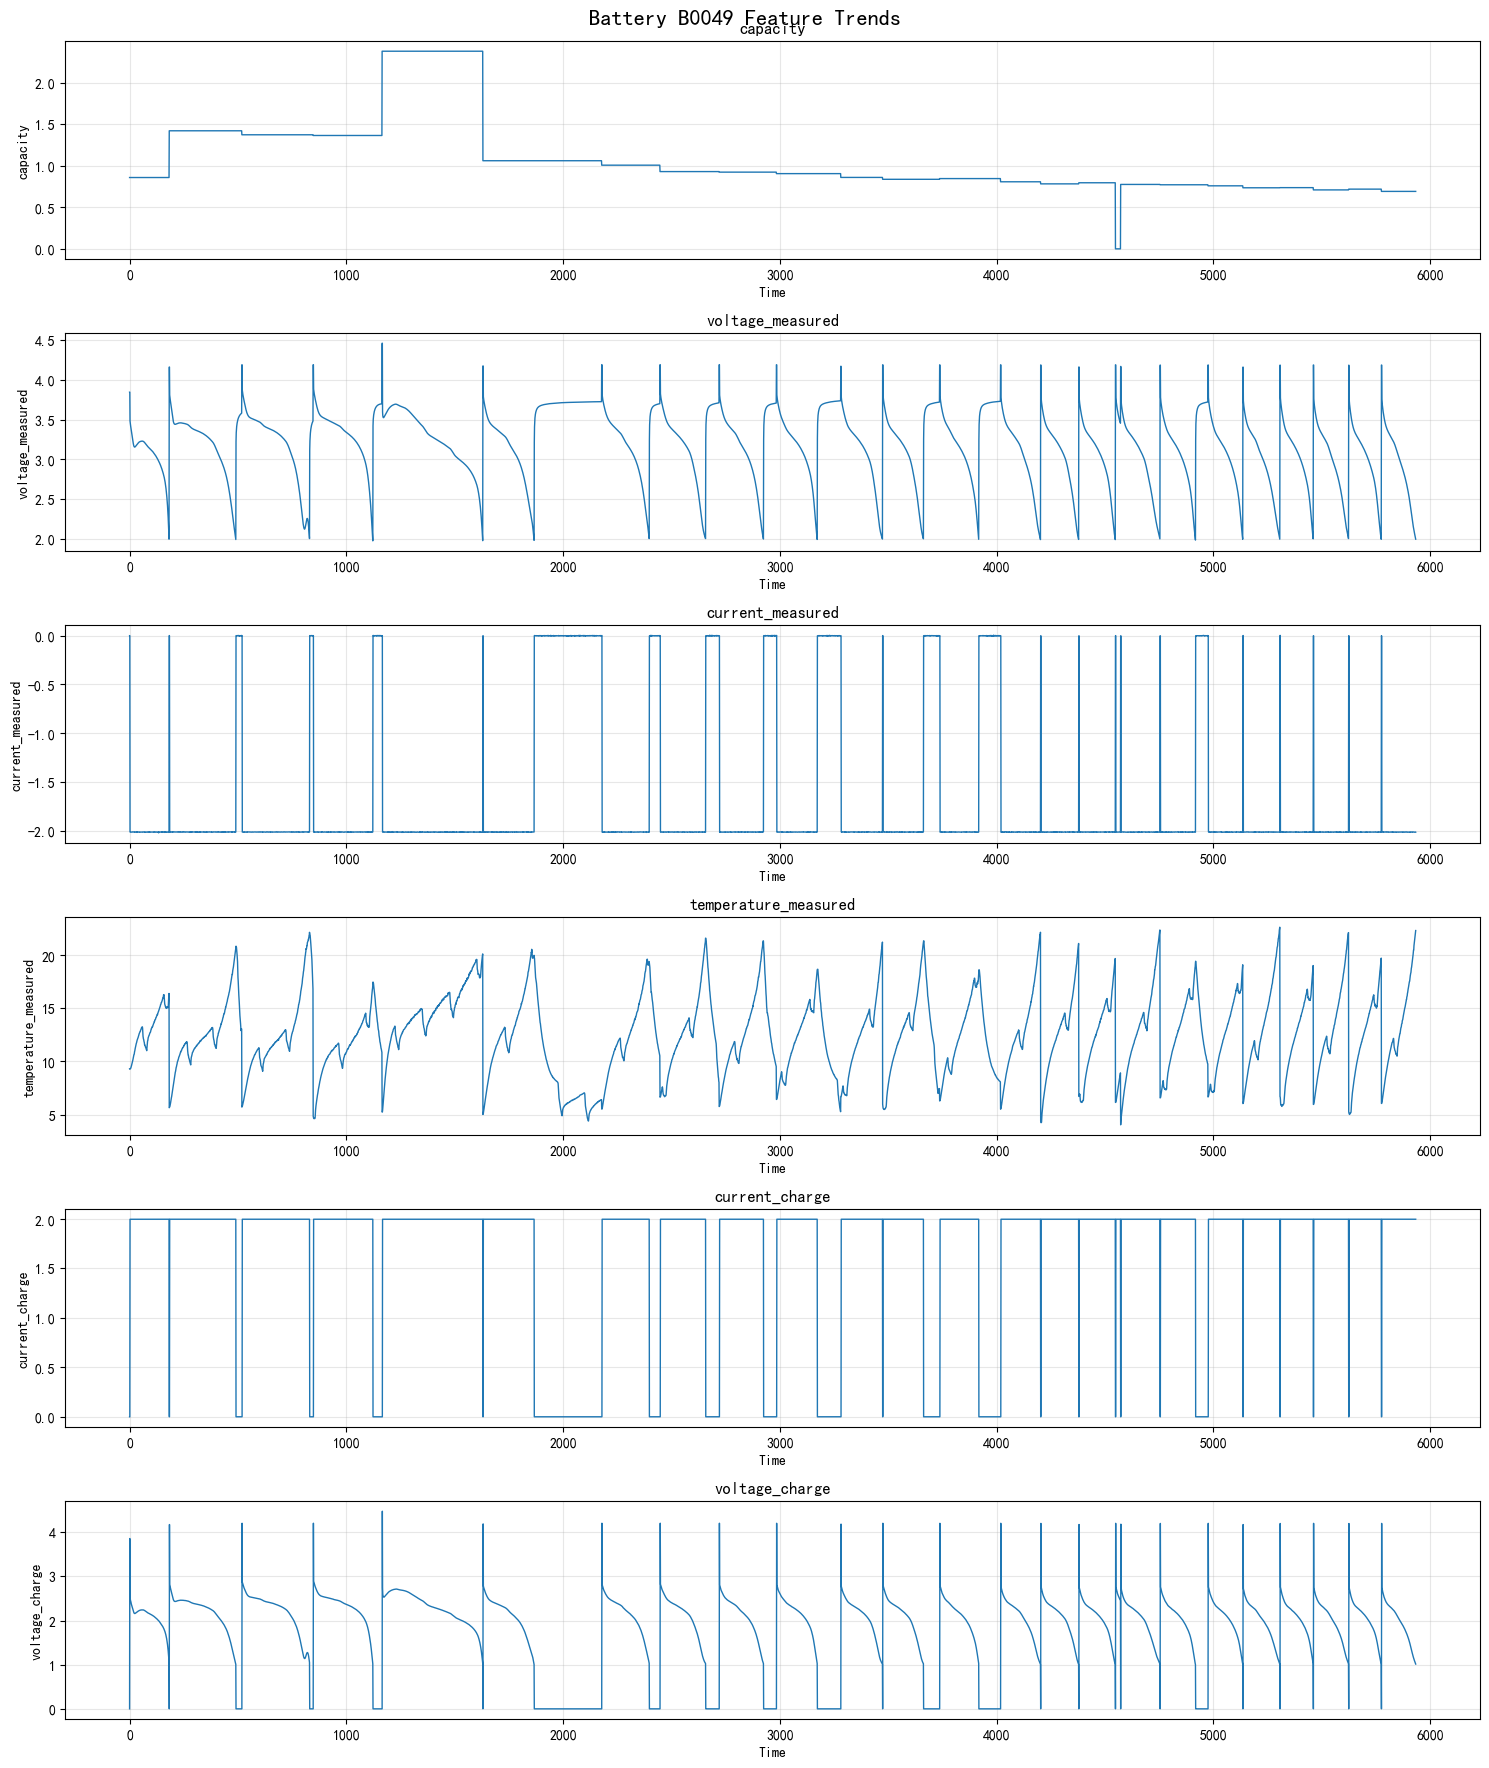

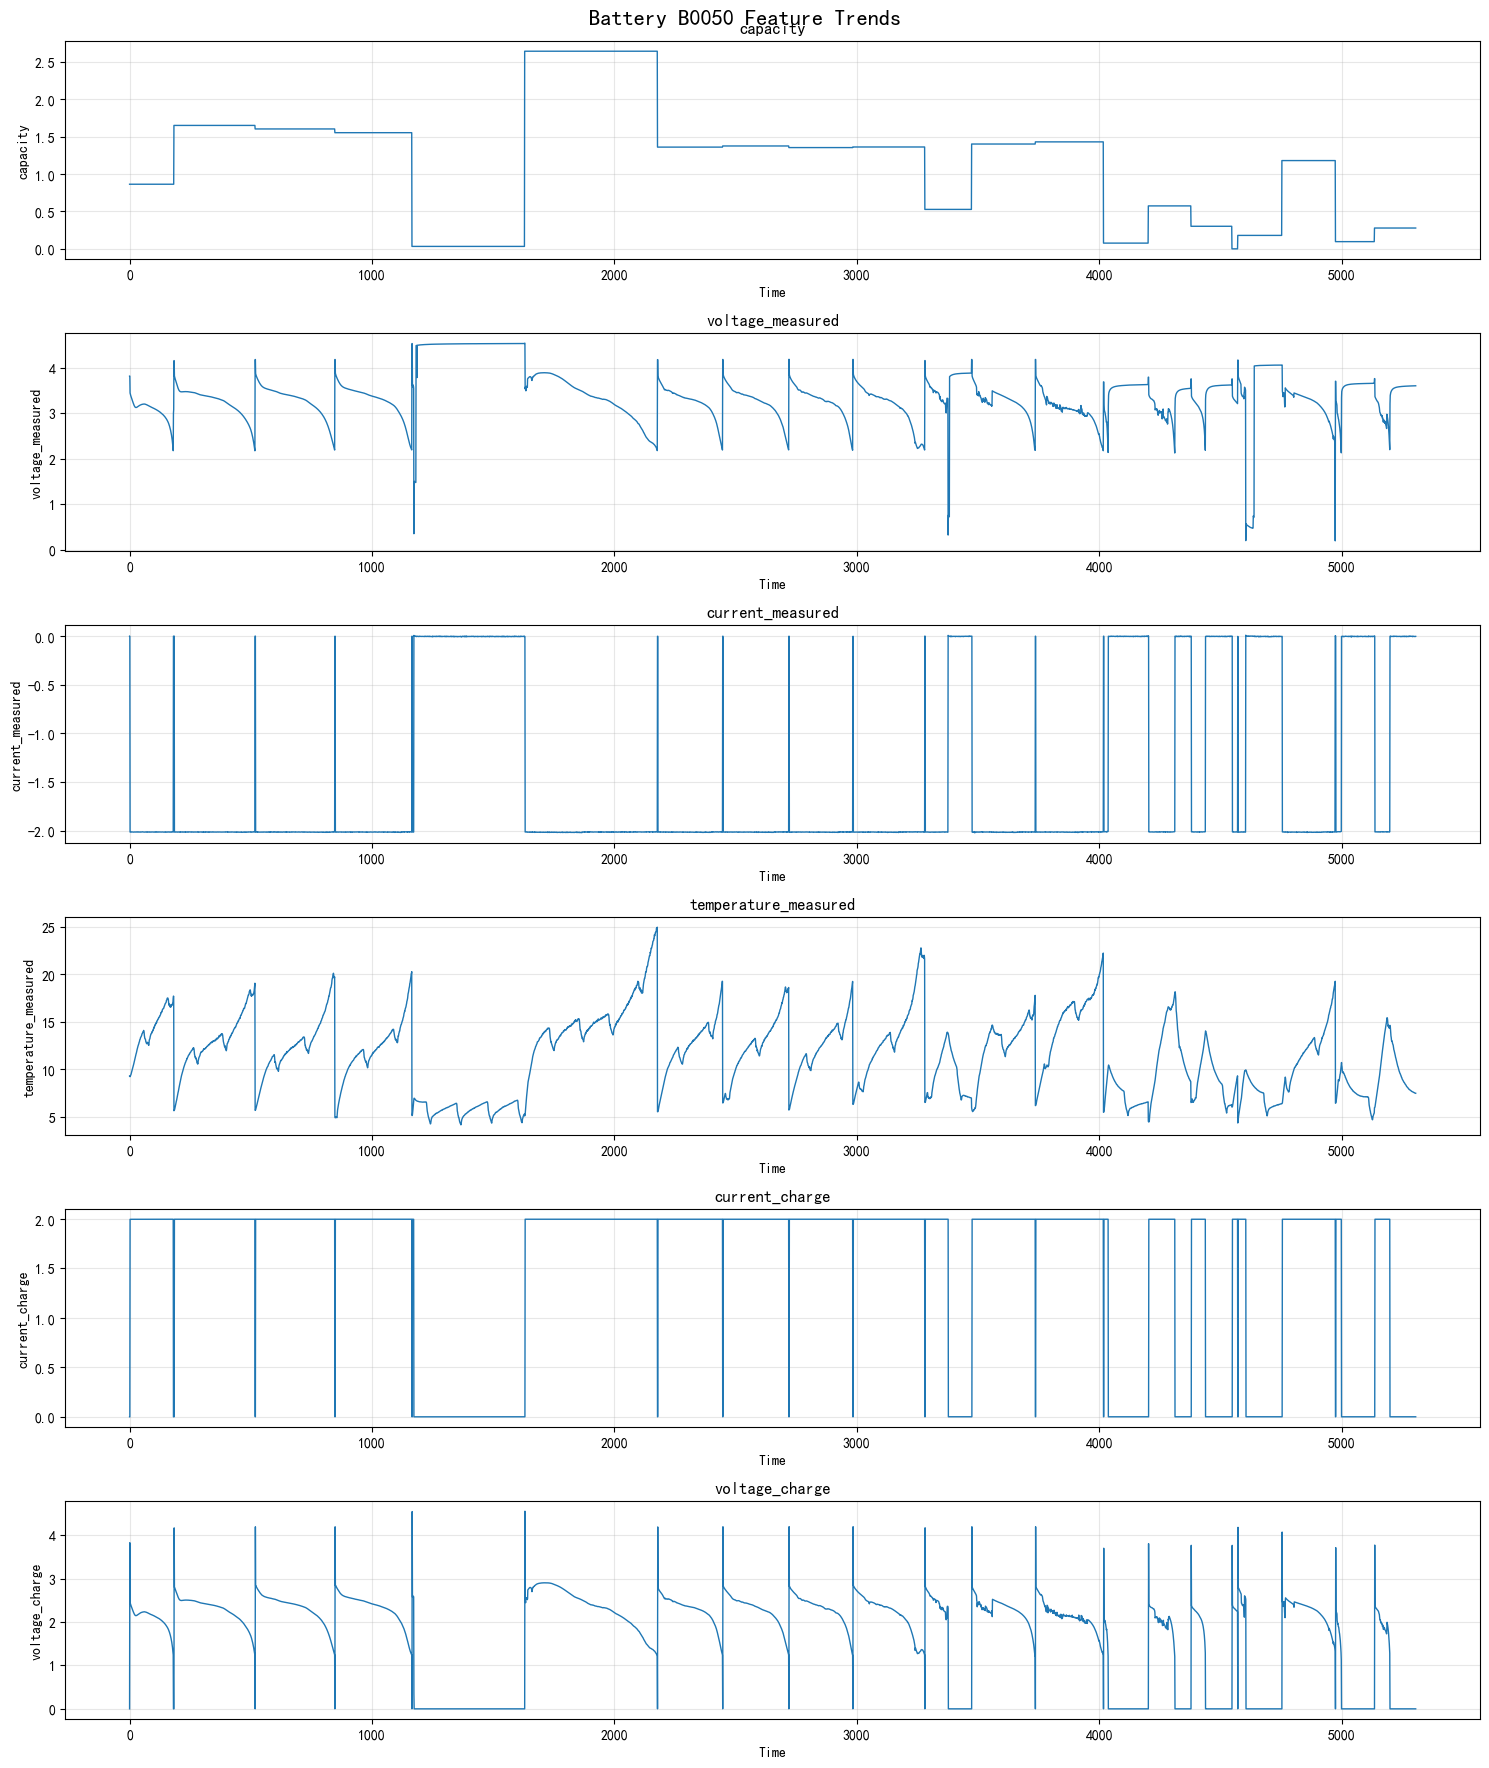

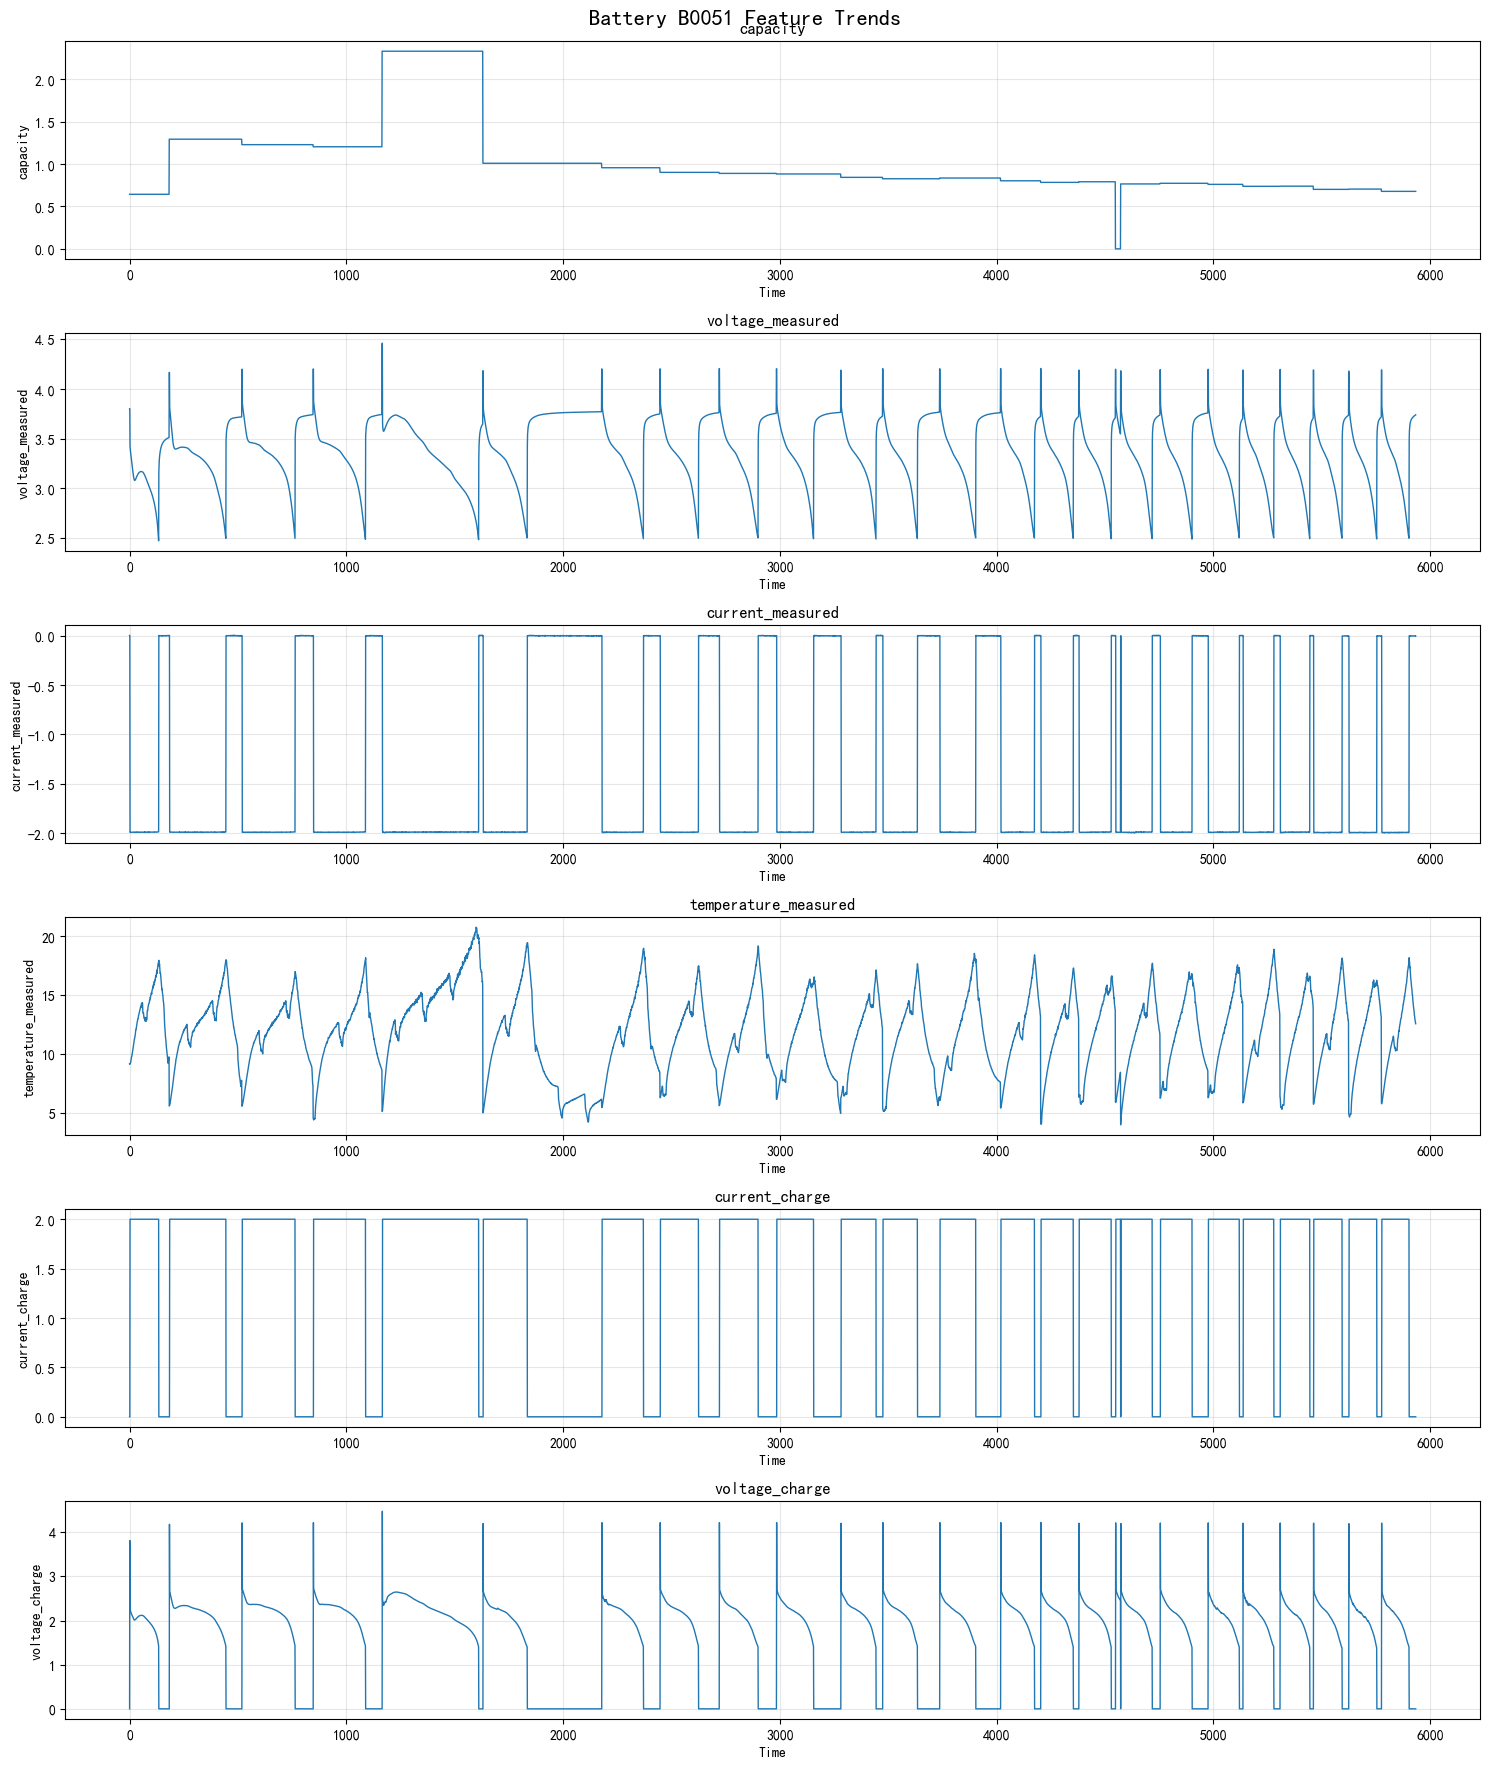

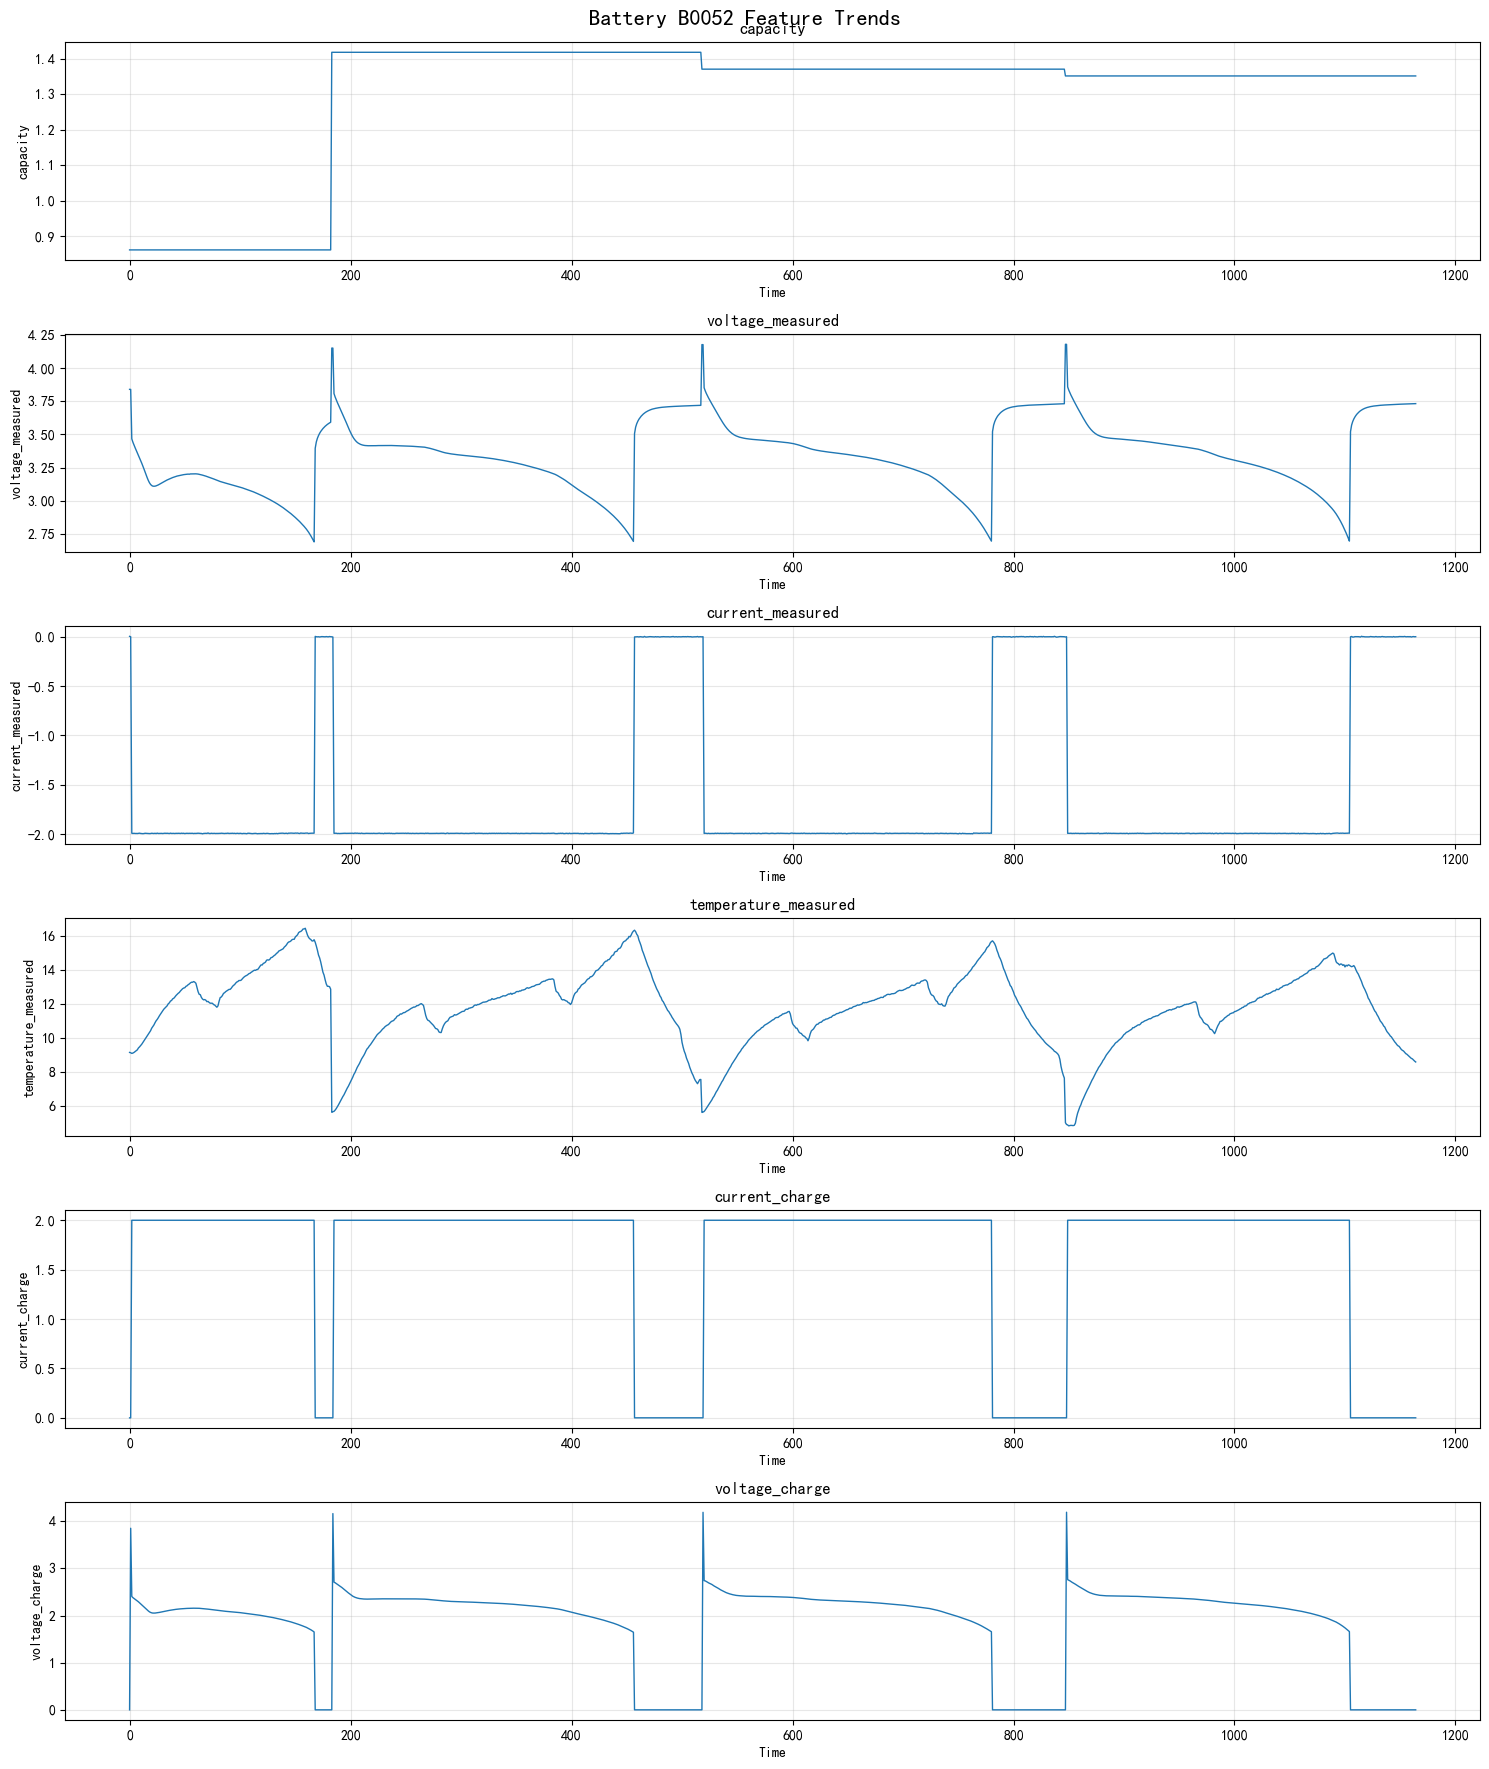

In [31]:
# Visualize feature trends for each battery separately
visualize_battery_features_separate(battery_data)